Task 1:Exploratory Data Analysis

In [1]:
pip install pandas matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your data
df = pd.read_csv("Data/raw_analyst_ratings.csv")

Descriptive Statistics
1 Headline Length Analysis

In [3]:
df['headline_length'] = df['headline'].astype(str).apply(len)

df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

Visualize headline length distribution

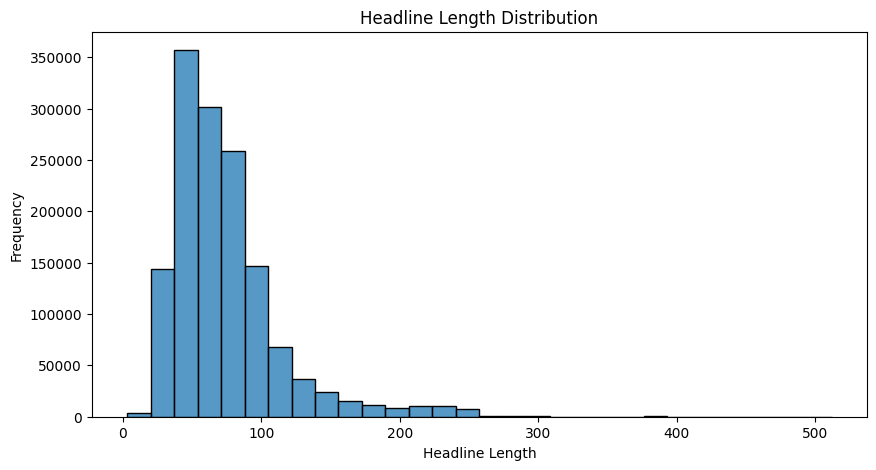

In [4]:
plt.figure(figsize=(10,5))
sns.histplot(df['headline_length'], bins=30)
plt.title('Headline Length Distribution')
plt.xlabel('Headline Length')
plt.ylabel('Frequency')
plt.show()

Count Articles Per Publisher

In [5]:
publisher_counts = df['publisher'].value_counts()

publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

The most active 10 are listed in the above section.

Visualize top publishers

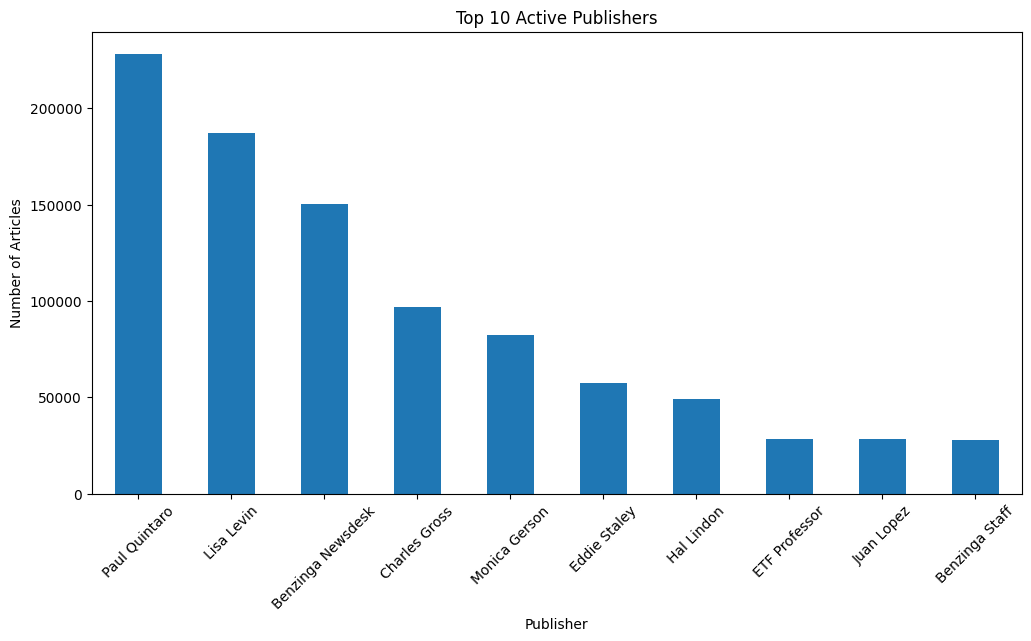

In [6]:
top_publishers = publisher_counts.head(10)

plt.figure(figsize=(12,6))
top_publishers.plot(kind='bar')
plt.title('Top 10 Active Publishers')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

Publication Trends Over Time

In [7]:
from datetime import datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

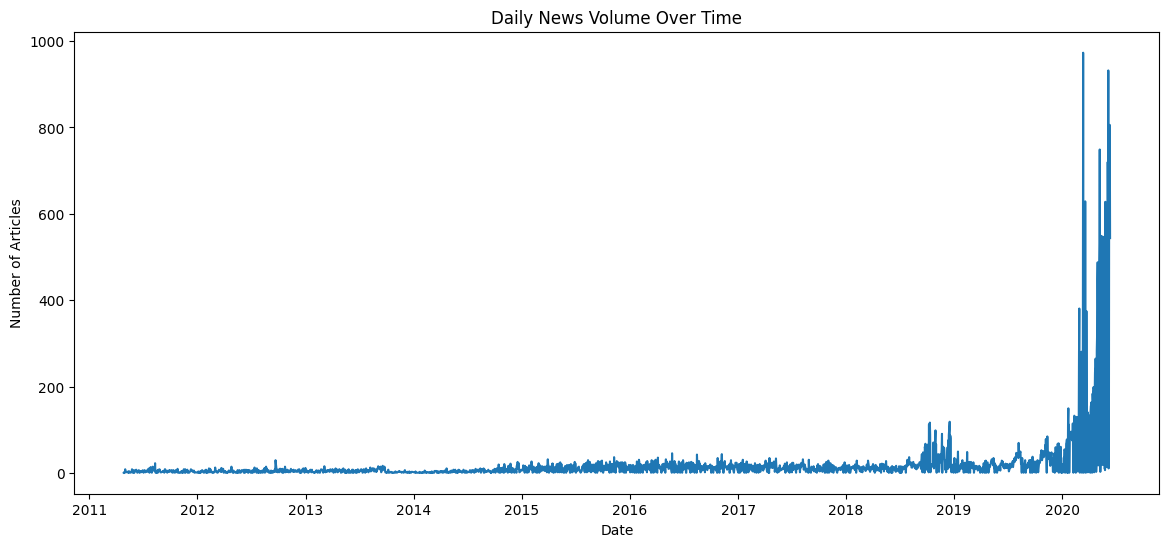

In [8]:
df['publication_day'] = df['date'].dt.date    
daily_news = df.groupby('publication_day').size()
plt.figure(figsize=(14,6))
daily_news.plot()
plt.title('Daily News Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.show()

There is high spike observed in the year 2020.

Text Analysis (Topic Modeling)

1 Common Keywords Using CountVectorizer

In [9]:
#imorting libraries to be used for exracting keywords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

# --- Task 1A: Get Multi-Word Phrases without changing df ---
phrase_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 3),   # Looks for 2-word and 3-word combinations
    max_features=20
)

# We fit using df['headline'] but save the output to a completely separate 'X_phrases' matrix
X_phrases = phrase_vectorizer.fit_transform(df['headline'].astype(str))

phrase_counts = pd.DataFrame({
    'phrase': phrase_vectorizer.get_feature_names_out(),
    'count': X_phrases.toarray().sum(axis=0)
}).sort_values(by='count', ascending=False)

print("--- TOP RECURRING PHRASES ---")
print(phrase_counts.head(10))

--- TOP RECURRING PHRASES ---
                phrase  count
0              52 week  51006
11        price target  47274
17       stocks moving  40044
8              mid day  37324
7        market update  33101
4   earnings scheduled  32055
5   initiates coverage  28993
9           pre market  28393
15           raises pt  27213
3    companies trading  23170


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# --- Task 2: Uncover Latent Themes using TF-IDF + LDA ---
tfidf_vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df['headline'].astype(str))

# Create and fit the Topic Model (Extracting 3 core themes)
num_themes = 3
lda_model = LatentDirichletAllocation(n_components=num_themes, random_state=42)
lda_model.fit(X_tfidf)

# Print the top keywords making up each individual topic cluster
feature_names = tfidf_vectorizer.get_feature_names_out()

print("--- TASK 2: EXTRACTED RECURRING THEMES ---")
for theme_idx, topic in enumerate(lda_model.components_):
    top_features_indices = topic.argsort()[:-4 - 1:-1]
    top_features = [feature_names[i] for i in top_features_indices]
    print(f"Theme {theme_idx + 1}: {', '.join(top_features)}")

KeyboardInterrupt: 

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# --- Fix 1: Take a random sample of 30,000 rows if the dataset is large ---
# This preserves your original 'df' entirely but pulls a temporary sample for LDA
df_sample = df.sample(n=30000, random_state=42) if len(df) > 30000 else df

# Vectorize the text from the sample dataset
tfidf_vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df_sample['headline'].astype(str))

# --- Fix 2 & 3: Use 'online' learning and parallel processing (n_jobs=-1) ---
num_themes = 3
lda_model = LatentDirichletAllocation(
    n_components=num_themes, 
    learning_method='online',  # Processes in small, fast mini-batches
    batch_size=128,            # Size of mini-batches
    n_jobs=-1,                 # Uses 100% of your computer's CPU cores
    random_state=42
)
lda_model.fit(X_tfidf)

# Print the top keywords making up each individual topic cluster
feature_names = tfidf_vectorizer.get_feature_names_out()

print("--- TASK 2: EXTRACTED RECURRING THEMES ---")
for theme_idx, topic in enumerate(lda_model.components_):
    top_features_indices = topic.argsort()[:-4 - 1:-1]
    top_features = [feature_names[i] for i in top_features_indices]
    print(f"Theme {theme_idx + 1}: {', '.join(top_features)}")

--- TASK 2: EXTRACTED RECURRING THEMES ---
Theme 1: vs, est, reports, eps
Theme 2: announces, buy, shares, pt
Theme 3: stocks, market, week, 52


As it can be observed,the common words with there amount of times found on the headlines is found in the above section. And also the theme for the words is also made.

Time Series Analysis of News Volume

1.News Frequency Over Time

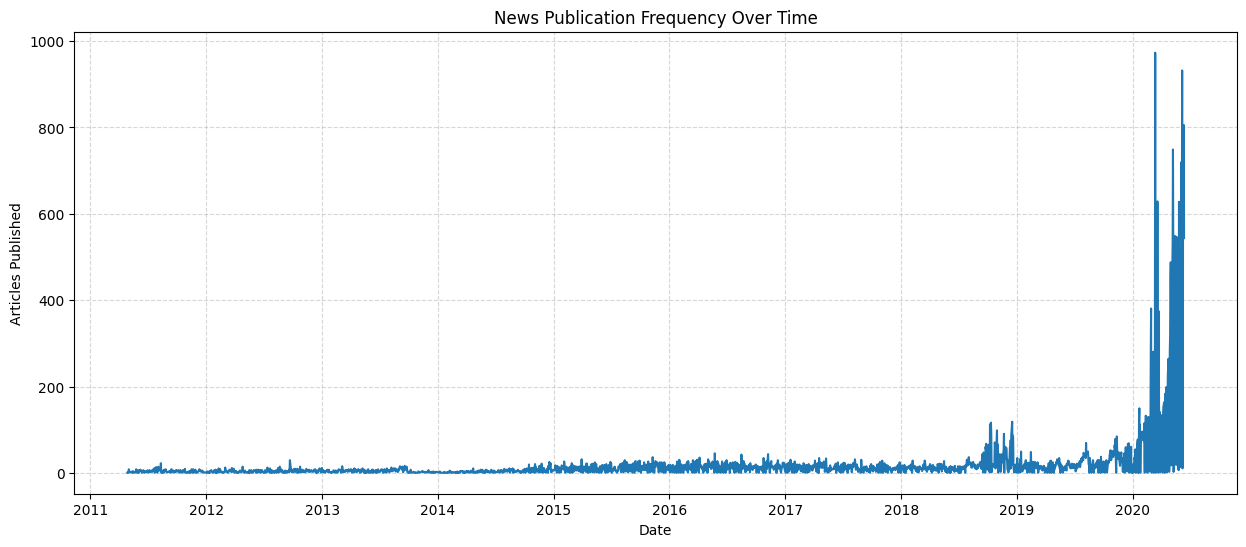

In [14]:
import matplotlib.pyplot as plt

# 1. Convert the 'date' column inside your df safely
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 2. Create a temporary cleaned dataset just for plotting so we don't lose rows in df
df_plot_clean = df.dropna(subset=['date'])

# 3. Group by the dates and count publications
news_per_day = df_plot_clean.groupby(df_plot_clean['date'].dt.date).size()

# 4. Plot the publication frequency chart
plt.figure(figsize=(15,6))
news_per_day.plot()
plt.title('News Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Articles Published')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

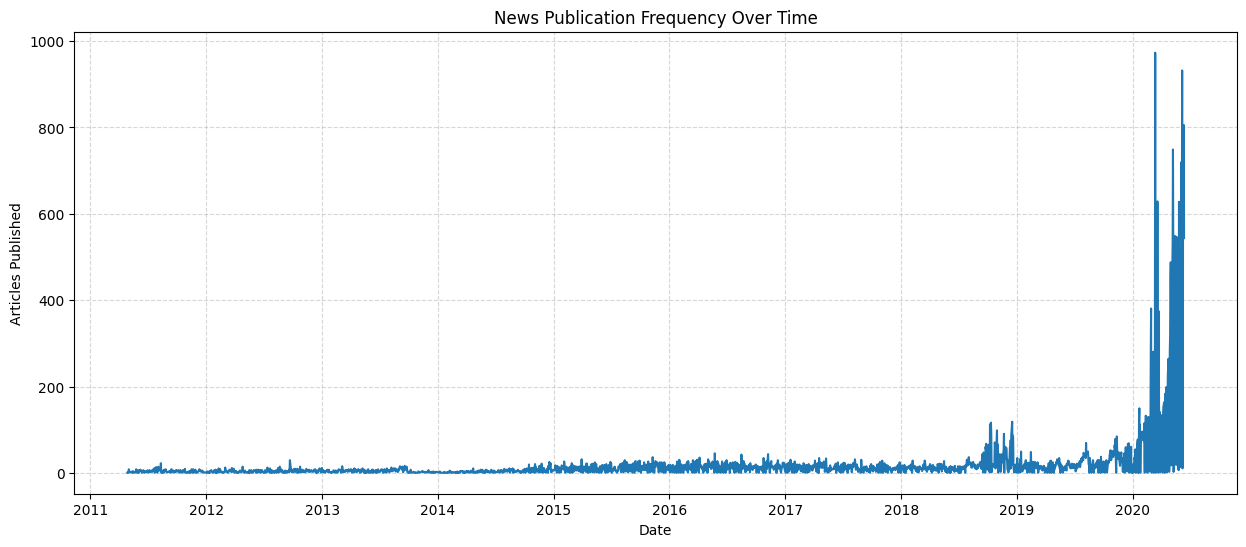

In [15]:
import matplotlib.pyplot as plt

# 1. Double-check if 'date' is actually the index instead of a column
if 'date' not in df.columns and df.index.name == 'date':
    # If it's the index, reset it back to a normal column temporarily
    df_plot = df.reset_index()
else:
    df_plot = df.copy()

# 2. Re-ensure it is in datetime format, dropping any rows with broken dates
df_plot['date'] = pd.to_datetime(df_plot['date'], errors='coerce')
df_plot = df_plot.dropna(subset=['date'])

# 3. Group by the date and count articles
news_per_day = df_plot.groupby(df_plot['date'].dt.date).size()

# 4. Plot the graph
plt.figure(figsize=(15,6))
news_per_day.plot()
plt.title('News Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Articles Published')
plt.grid(True, linestyle='--', alpha=0.5)  # Adds a clean grid line
plt.show()

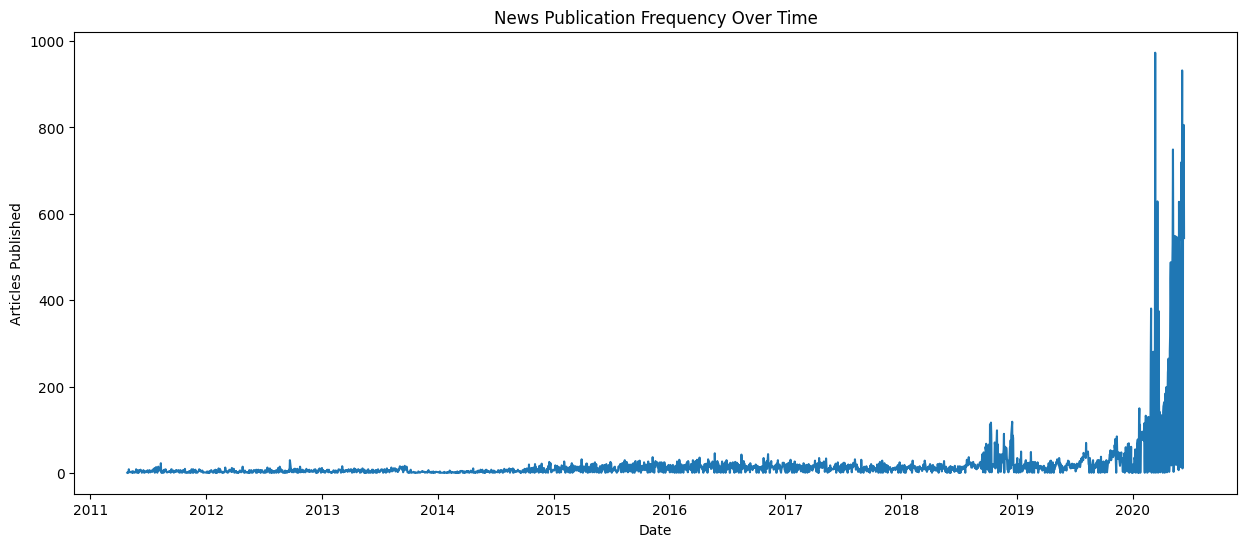

In [16]:
# 1. Convert the column to datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Now group and plot
news_per_day = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(15,6))
news_per_day.plot()
plt.title('News Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Articles Published')
plt.show()

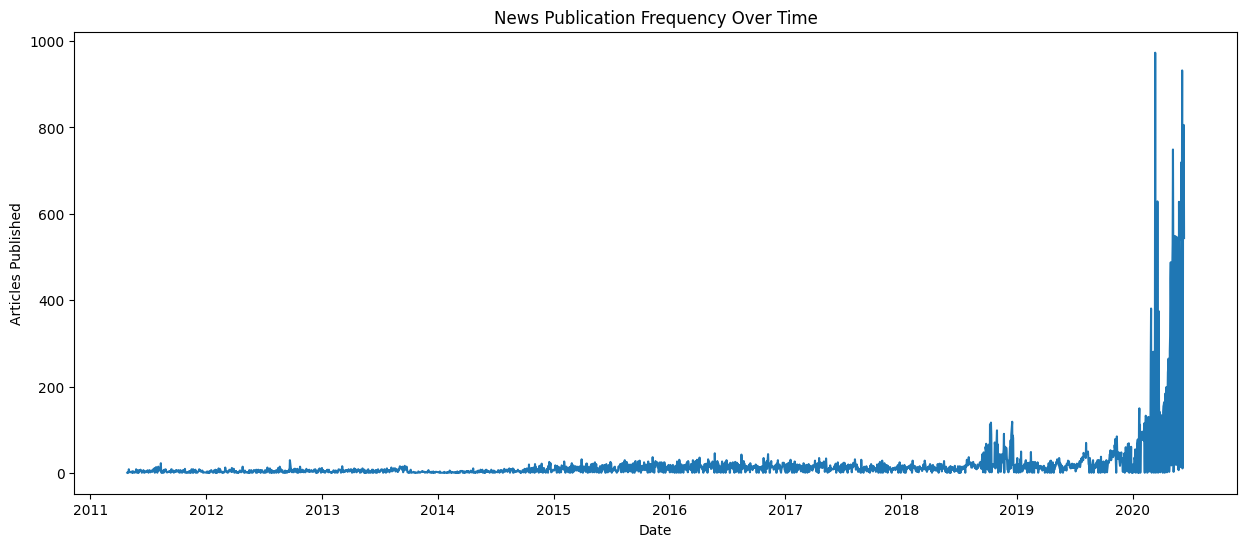

In [17]:
news_per_day = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(15,6))
news_per_day.plot()
plt.title('News Publication Frequency Over Time')
plt.xlabel('Date')
plt.ylabel('Articles Published')
plt.show()

6.2 Identify Spikes

In [18]:
top_spikes = news_per_day.sort_values(ascending=False).head(10)

top_spikes

date
2020-03-12    973
2020-06-05    932
2020-06-10    806
2020-06-09    804
2020-06-08    765
2020-05-07    749
2020-06-03    720
2020-03-19    629
2020-05-26    628
2020-05-13    549
dtype: int64

You can discuss possible reasons:
earnings season
mergers
FDA announcements
economic reports
This satisfies:
✔ Identify spikes and relate them to events

6.3 Analyze Publishing Hours

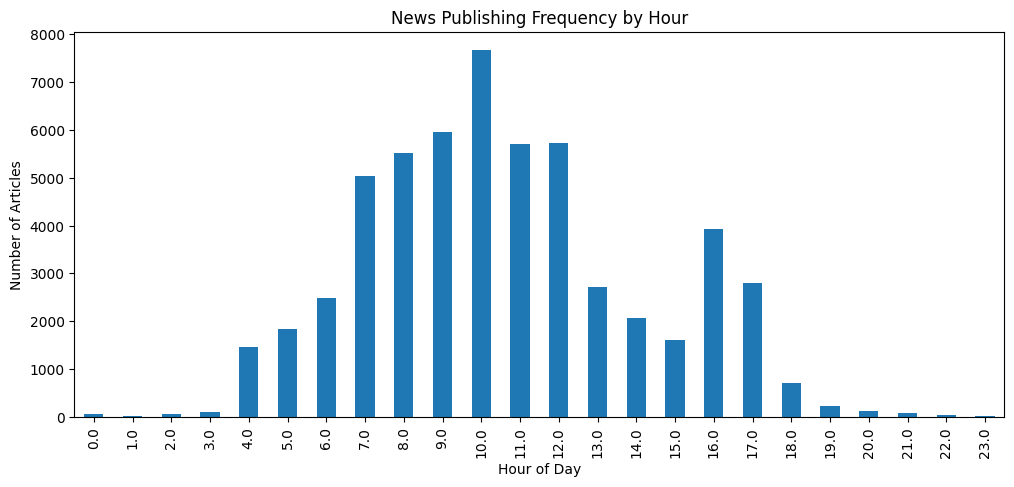

In [19]:
df['hour'] = df['date'].dt.hour
hourly_news = df.groupby('hour').size()
plt.figure(figsize=(12,5))
hourly_news.plot(kind='bar')
plt.title('News Publishing Frequency by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Articles')
plt.show()

7.Publisher Analysis
7.1 Most Active Publishers

In [20]:
top_publishers = df['publisher'].value_counts().head(20)

top_publishers

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Allie Wickman         18317
Shanthi Rexaline      16640
Craig Jones           16221
Wayne Duggan          12897
Nelson Hem            12590
Name: count, dtype: int64

7.2 Extract Email Domains
Some publishers may appear as emails.
Extract domains.

In [21]:
df['publisher_domain'] = df['publisher'].astype(str).str.extract(r'@([\w\.-]+)')
domain_counts = df['publisher_domain'].value_counts()

domain_counts.head(10)

publisher_domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

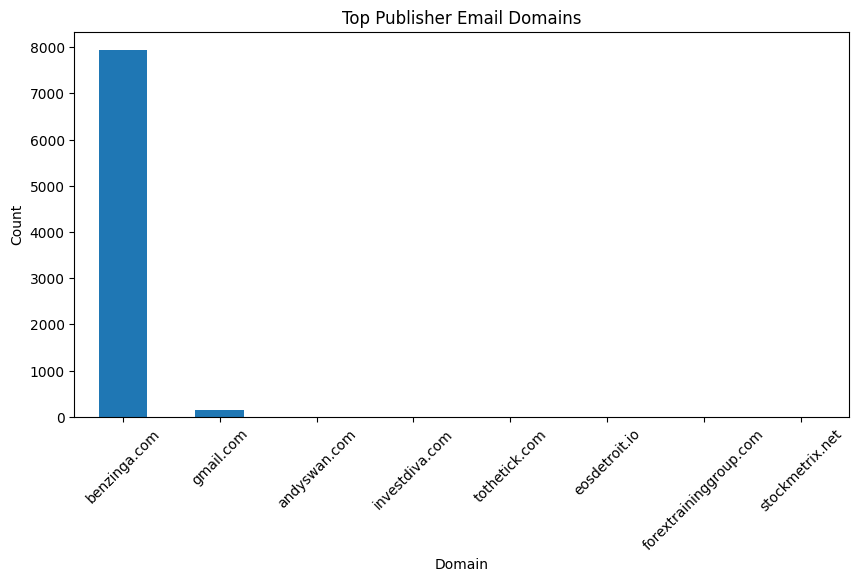

In [22]:
plt.figure(figsize=(10,5))
domain_counts.head(10).plot(kind='bar')
plt.title('Top Publisher Email Domains')
plt.xlabel('Domain')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

8. Final Insights / Conclusions
End the notebook with observations such as:
Most headlines focus on earnings and stock ratings
Certain publishers dominate financial reporting
News volume spikes during major market events
Most articles are released during trading hours
Topic modeling reveals recurring financial themes